<a href="https://colab.research.google.com/github/HK25abm/Transformer-Phishing-Detection/blob/main/DeBERTa_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No GPU is connected.")

CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q transformers accelerate sentencepiece scikit-learn pandas matplotlib

In [3]:
import gc
import os
import random
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed
)

In [5]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (14000, 6)
Validation: (3000, 6)
Testing: (3000, 6)


In [6]:
def prepare_split(frame):
    frame = frame.copy()

    frame = frame.dropna(
        subset=["text", "label"]
    )

    frame["text"] = (
        frame["text"]
        .astype(str)
        .str.strip()
    )

    frame["label"] = pd.to_numeric(
        frame["label"],
        errors="coerce"
    )

    frame = frame.dropna(
        subset=["label"]
    )

    frame["label"] = frame["label"].astype(int)

    frame = frame[
        frame["label"].isin([0, 1])
    ]

    frame = frame[
        frame["text"].str.len() > 0
    ]

    return frame.reset_index(drop=True)


train_df = prepare_split(train_df)
val_df = prepare_split(val_df)
test_df = prepare_split(test_df)

In [7]:
for name, frame in {
    "Training": train_df,
    "Validation": val_df,
    "Testing": test_df
}.items():
    print(f"\n{name}:")
    print(frame["label"].value_counts())
    print("Missing values:")
    print(frame[["text", "label"]].isna().sum())


Training:
label
0    7000
1    7000
Name: count, dtype: int64
Missing values:
text     0
label    0
dtype: int64

Validation:
label
1    1500
0    1500
Name: count, dtype: int64
Missing values:
text     0
label    0
dtype: int64

Testing:
label
0    1500
1    1500
Name: count, dtype: int64
Missing values:
text     0
label    0
dtype: int64


In [8]:
train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print(
    "Train-validation overlap:",
    len(train_texts & val_texts)
)

print(
    "Train-test overlap:",
    len(train_texts & test_texts)
)

print(
    "Validation-test overlap:",
    len(val_texts & test_texts)
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [9]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

In [10]:
MODEL_CHECKPOINT = "microsoft/deberta-v3-base"
MAX_LENGTH = 256

deberta_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_CHECKPOINT,
    use_fast=True
)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

In [11]:
class EmailDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length=256
    ):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            self.texts[index],
            truncation=True,
            max_length=self.max_length
        )

        encoding["labels"] = int(
            self.labels[index]
        )

        return encoding

In [12]:
deberta_train_dataset = EmailDataset(
    train_df["text"],
    train_df["label"],
    deberta_tokenizer,
    max_length=MAX_LENGTH
)

deberta_val_dataset = EmailDataset(
    val_df["text"],
    val_df["label"],
    deberta_tokenizer,
    max_length=MAX_LENGTH
)

deberta_test_dataset = EmailDataset(
    test_df["text"],
    test_df["label"],
    deberta_tokenizer,
    max_length=MAX_LENGTH
)

In [13]:
deberta_data_collator = DataCollatorWithPadding(
    tokenizer=deberta_tokenizer
)

In [14]:
def stable_softmax(logits):
    logits = np.asarray(
        logits,
        dtype=np.float64
    )

    logits = np.nan_to_num(
        logits,
        nan=0.0,
        posinf=1e4,
        neginf=-1e4
    )

    shifted = logits - np.max(
        logits,
        axis=1,
        keepdims=True
    )

    exponentials = np.exp(shifted)

    return exponentials / np.sum(
        exponentials,
        axis=1,
        keepdims=True
    )


def compute_metrics(eval_prediction):
    logits, labels = eval_prediction

    probabilities = stable_softmax(logits)
    predictions = np.argmax(
        probabilities,
        axis=1
    )

    results = {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        )
    }

    if len(np.unique(labels)) == 2:
        results["roc_auc"] = roc_auc_score(
            labels,
            probabilities[:, 1]
        )

    return results

In [15]:
gc.collect()
torch.cuda.empty_cache()

deberta_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=2,
        torch_dtype=torch.float32,
        id2label={
            0: "Legitimate",
            1: "Phishing"
        },
        label2id={
            "Legitimate": 0,
            "Phishing": 1
        }
    )
)

print(
    "Model dtype:",
    next(deberta_model.parameters()).dtype
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  371MB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier

Model dtype: torch.float32


In [16]:
deberta_training_args = TrainingArguments(
    output_dir="./deberta_checkpoints",

    learning_rate=1e-5,

    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=8,

    num_train_epochs=3,
    weight_decay=0.01,

    warmup_ratio=0.10,
    max_grad_norm=1.0,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,

    fp16=False,
    bf16=False,

    report_to="none",
    seed=SEED,
    data_seed=SEED
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [17]:
deberta_trainer = Trainer(
    model=deberta_model,
    args=deberta_training_args,

    train_dataset=deberta_train_dataset,
    eval_dataset=deberta_val_dataset,

    data_collator=deberta_data_collator,
    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print(
    "Trainer device:",
    deberta_trainer.args.device
)

print(
    "Model dtype:",
    next(deberta_model.parameters()).dtype
)

Trainer device: cuda:0
Model dtype: torch.float32


In [18]:
deberta_start_time = time.time()

deberta_train_output = deberta_trainer.train()

deberta_training_time = (
    time.time() - deberta_start_time
)

print(
    "Training time:",
    round(deberta_training_time, 2),
    "seconds"
)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.277055,0.048569,0.990333,0.994620,0.986000,0.990291,0.999293
2,0.262673,0.056366,0.989333,0.988682,0.990000,0.989340,0.999170
3,0.066841,0.059128,0.990667,0.991979,0.989333,0.990654,0.999372


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 3077.27 seconds


In [19]:
deberta_prediction_output = (
    deberta_trainer.predict(
        deberta_test_dataset
    )
)

deberta_logits = (
    deberta_prediction_output.predictions
)

deberta_y_true = (
    deberta_prediction_output.label_ids
)

deberta_probabilities = stable_softmax(
    deberta_logits
)

deberta_y_pred = np.argmax(
    deberta_probabilities,
    axis=1
)

In [20]:
deberta_prediction_output = (
    deberta_trainer.predict(
        deberta_test_dataset
    )
)

deberta_logits = (
    deberta_prediction_output.predictions
)

deberta_y_true = (
    deberta_prediction_output.label_ids
)

deberta_probabilities = stable_softmax(
    deberta_logits
)

deberta_y_pred = np.argmax(
    deberta_probabilities,
    axis=1
)

In [21]:
deberta_accuracy = accuracy_score(
    deberta_y_true,
    deberta_y_pred
)

deberta_precision = precision_score(
    deberta_y_true,
    deberta_y_pred,
    zero_division=0
)

deberta_recall = recall_score(
    deberta_y_true,
    deberta_y_pred,
    zero_division=0
)

deberta_f1 = f1_score(
    deberta_y_true,
    deberta_y_pred,
    zero_division=0
)

deberta_auc = roc_auc_score(
    deberta_y_true,
    deberta_probabilities[:, 1]
)

In [22]:
print("Accuracy:", round(deberta_accuracy, 4))
print("Precision:", round(deberta_precision, 4))
print("Recall:", round(deberta_recall, 4))
print("F1-score:", round(deberta_f1, 4))
print("ROC-AUC:", round(deberta_auc, 6))

Accuracy: 0.9897
Precision: 0.99
Recall: 0.9893
F1-score: 0.9897
ROC-AUC: 0.999216


In [23]:
print(
    classification_report(
        deberta_y_true,
        deberta_y_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9893    0.9900    0.9897      1500
    Phishing     0.9900    0.9893    0.9897      1500

    accuracy                         0.9897      3000
   macro avg     0.9897    0.9897    0.9897      3000
weighted avg     0.9897    0.9897    0.9897      3000



In [24]:
RESULTS_FOLDER = "DeBERTa_Results"

os.makedirs(
    RESULTS_FOLDER,
    exist_ok=True
)

In [25]:
deberta_metrics = {
    "Model": "DeBERTa",
    "Checkpoint": MODEL_CHECKPOINT,
    "Accuracy": deberta_accuracy,
    "Precision": deberta_precision,
    "Recall": deberta_recall,
    "F1-score": deberta_f1,
    "ROC-AUC": deberta_auc,
    "Training Time Seconds": deberta_training_time,
    "Maximum Sequence Length": MAX_LENGTH,
    "Epochs": 3,
    "Learning Rate": 1e-5,
    "Precision Mode": "FP32"
}

deberta_results_df = pd.DataFrame(
    [deberta_metrics]
)

deberta_results_df.to_csv(
    f"{RESULTS_FOLDER}/deberta_results.csv",
    index=False
)

deberta_results_df

,Model,Checkpoint,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time Seconds,Maximum Sequence Length,Epochs,Learning Rate,Precision Mode
0,DeBERTa,microsoft/deberta-v3-base,0.989667,0.989993,0.989333,0.989663,0.999216,3077.268993,256,3,0.00001,FP32


In [26]:
deberta_predictions_df = test_df.copy()

deberta_predictions_df[
    "predicted_label"
] = deberta_y_pred

deberta_predictions_df[
    "predicted_class"
] = deberta_predictions_df[
    "predicted_label"
].map({
    0: "Legitimate",
    1: "Phishing"
})

deberta_predictions_df[
    "legitimate_probability"
] = deberta_probabilities[:, 0]

deberta_predictions_df[
    "phishing_probability"
] = deberta_probabilities[:, 1]

deberta_predictions_df[
    "correct_prediction"
] = (
    deberta_predictions_df["label"]
    == deberta_predictions_df["predicted_label"]
)

deberta_predictions_df.to_csv(
    f"{RESULTS_FOLDER}/deberta_predictions.csv",
    index=False
)

In [27]:
deberta_report = classification_report(
    deberta_y_true,
    deberta_y_pred,
    target_names=[
        "Legitimate",
        "Phishing"
    ],
    digits=4,
    output_dict=True
)

pd.DataFrame(
    deberta_report
).transpose().to_csv(
    f"{RESULTS_FOLDER}/deberta_classification_report.csv"
)

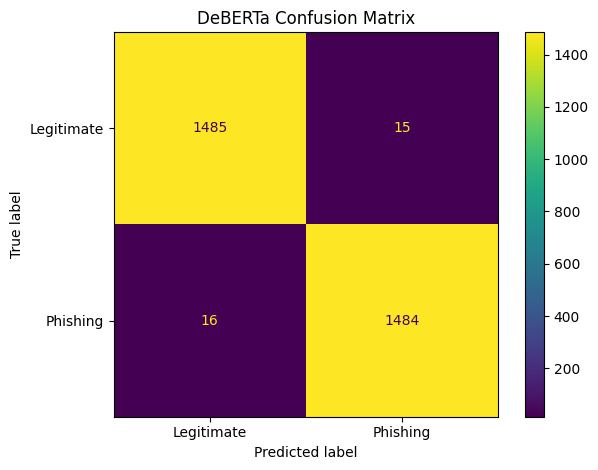

In [28]:
deberta_cm = confusion_matrix(
    deberta_y_true,
    deberta_y_pred
)

display = ConfusionMatrixDisplay(
    confusion_matrix=deberta_cm,
    display_labels=[
        "Legitimate",
        "Phishing"
    ]
)

display.plot(
    values_format="d"
)

plt.title("DeBERTa Confusion Matrix")
plt.tight_layout()

plt.savefig(
    f"{RESULTS_FOLDER}/deberta_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

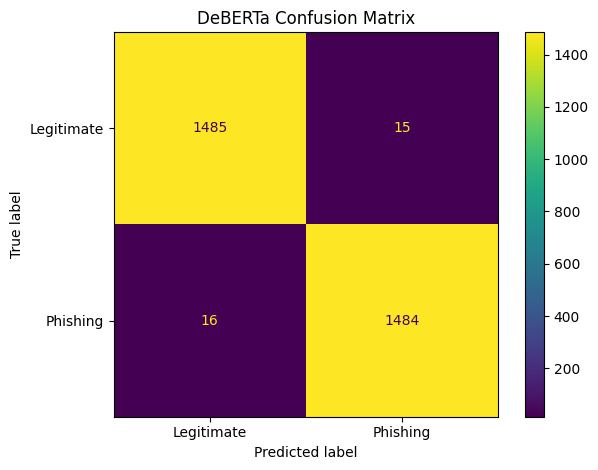

In [29]:
deberta_cm = confusion_matrix(
    deberta_y_true,
    deberta_y_pred
)

display = ConfusionMatrixDisplay(
    confusion_matrix=deberta_cm,
    display_labels=[
        "Legitimate",
        "Phishing"
    ]
)

display.plot(
    values_format="d"
)

plt.title("DeBERTa Confusion Matrix")
plt.tight_layout()

plt.savefig(
    f"{RESULTS_FOLDER}/deberta_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

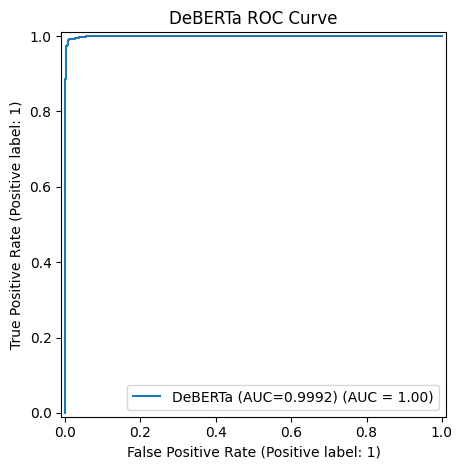

In [30]:
RocCurveDisplay.from_predictions(
    deberta_y_true,
    deberta_probabilities[:, 1],
    name=f"DeBERTa (AUC={deberta_auc:.4f})"
)

plt.title("DeBERTa ROC Curve")
plt.tight_layout()

plt.savefig(
    f"{RESULTS_FOLDER}/deberta_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [31]:
deberta_training_log = pd.DataFrame(
    deberta_trainer.state.log_history
)

deberta_training_log.to_csv(
    f"{RESULTS_FOLDER}/deberta_training_log.csv",
    index=False
)

In [32]:
MODEL_FOLDER = (
    f"{RESULTS_FOLDER}/deberta_model"
)

deberta_trainer.save_model(
    MODEL_FOLDER
)

deberta_tokenizer.save_pretrained(
    MODEL_FOLDER
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('DeBERTa_Results/deberta_model/tokenizer_config.json',
 'DeBERTa_Results/deberta_model/tokenizer.json')

In [33]:
experiment_information = pd.DataFrame([
    {
        "Model": "DeBERTa-v3-base",
        "Dataset": "Final multi-source dataset v2",
        "Training samples": len(train_df),
        "Validation samples": len(val_df),
        "Testing samples": len(test_df),
        "Learning rate": 1e-5,
        "Epochs": 3,
        "Maximum sequence length": MAX_LENGTH,
        "Physical training batch size": 4,
        "Gradient accumulation steps": 4,
        "Effective training batch size": 16,
        "Evaluation batch size": 8,
        "Precision mode": "FP32",
        "Random seed": SEED
    }
])

experiment_information.to_csv(
    f"{RESULTS_FOLDER}/deberta_experiment_information.csv",
    index=False
)

In [34]:
for root, directories, files in os.walk(
    RESULTS_FOLDER
):
    level = root.replace(
        RESULTS_FOLDER,
        ""
    ).count(os.sep)

    indent = "    " * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    sub_indent = "    " * (level + 1)

    for filename in files:
        print(
            f"{sub_indent}{filename}"
        )

DeBERTa_Results/
    deberta_roc_curve.png
    deberta_confusion_matrix.png
    deberta_classification_report.csv
    deberta_experiment_information.csv
    deberta_predictions.csv
    deberta_results.csv
    deberta_training_log.csv
    deberta_model/
        model.safetensors
        config.json
        tokenizer_config.json
        training_args.bin
        tokenizer.json


In [35]:
shutil.make_archive(
    "DeBERTa_Results",
    "zip",
    RESULTS_FOLDER
)

'/content/DeBERTa_Results.zip'

In [36]:
print(
    "ZIP exists:",
    os.path.exists(
        "DeBERTa_Results.zip"
    )
)

print(
    "ZIP size:",
    round(
        os.path.getsize(
            "DeBERTa_Results.zip"
        ) / 1024**2,
        2
    ),
    "MB"
)

ZIP exists: True
ZIP size: 608.07 MB


In [37]:
from google.colab import files

files.download(
    "DeBERTa_Results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>